# Tipping points: neural network robustness

A step further, we could disentangle numerical time scheme error and NN performance

## Identifying tipping points: manual study
Tipping points are highly sensitive points where a very small change in the initial conditions can generate a completely different trajectory (make one more turn or not). 

In [1]:
import matplotlib.pyplot as plt 
import jax
import numpy as np 
import equinox as eqx
import os
import jax.numpy as jnp
from datasets import init_dataloaders
from solvers.runge_kutta import RK_solver_fixed, RK_tableaux
from forecasters import *
from networks import *
from utils import *

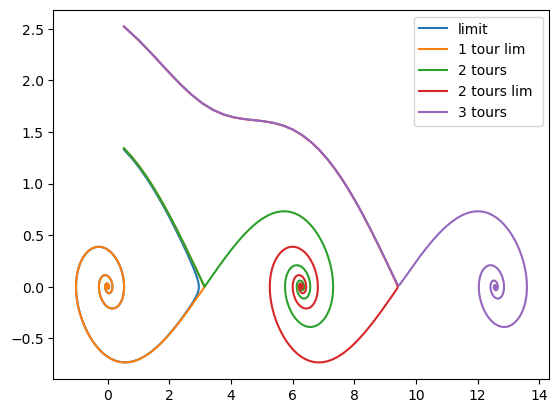

In [58]:
def F(y,t):
    q,p = y[0], y[1]
    return jnp.array([p, -(2*np.pi/12)**2 * jnp.sin(q)-0.2*p])

y0 = np.array([0.528,1.329]) # traj limite qui fait presque un tour
# 1 tour lim
y0_err = np.array([0.528,1.3423]) #np.array([0.528,1.329])#
y0_err2 = np.array([0.528,1.3424]) #np.array([0.528,1.329])#

# 2 tour lim 
y0_err3 = np.array([0.528,2.522]) #np.array([0.528,1.329])#
y0_err4 = np.array([0.528,2.523]) #np.array([0.528,1.329])#
dt_inf = 0.2 
t0 = 0
t1 =100

y_true,_,_,_ = RK_solver_fixed(F,y0,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_err,_,_,_ = RK_solver_fixed(F,y0_err,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_err2,_,_,_ = RK_solver_fixed(F,y0_err2,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_err3,_,_,_ = RK_solver_fixed(F,y0_err3,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
y_err4,_,_,_ = RK_solver_fixed(F,y0_err4,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
plt.plot(y_true[0,:],y_true[1,:],label="limit")
plt.plot(y_err[0,:],y_err[1,:],label="1 tour lim")
plt.plot(y_err2[0,:],y_err2[1,:],label="2 tours")
plt.plot(y_err3[0,:],y_err3[1,:],label="2 tours lim ")
plt.plot(y_err4[0,:],y_err4[1,:],label="3 tours")
plt.legend()
plt.show()



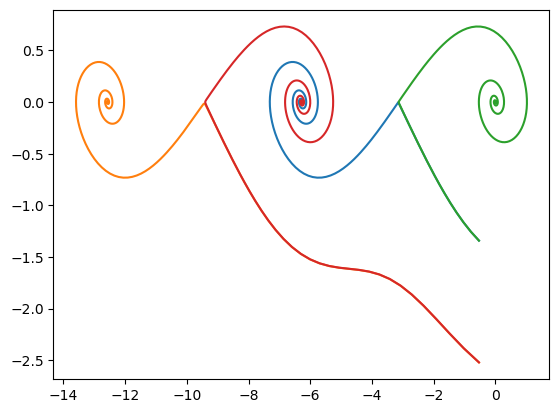

In [172]:
limit_points_real = np.array([[0.528,1.3423],
                       [0.528,2.522]])
tipping_points_real = np.array([[0.528,1.3424],
                               [0.528,2.523]])

y4,_,_,_ = RK_solver_fixed(F,-1*tipping_points_real[0],dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) 
y5,_,_,_ = RK_solver_fixed(F,-1*tipping_points_real[1],dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"])
y6, _,_,_ = RK_solver_fixed(F,-1*limit_points_real[0],dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"])
y7, _,_,_ = RK_solver_fixed(F,-1*limit_points_real[1],dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"])
plt.plot(y4[0,:],y4[1,:],label="1 tour lim")
plt.plot(y5[0,:],y5[1,:],label="2 tours lim")
plt.plot(y6[0,:],y6[1,:],label="1 tour")
plt.plot(y7[0,:],y7[1,:],label="2 tours")


Les points symétriques sont aussi solutions 

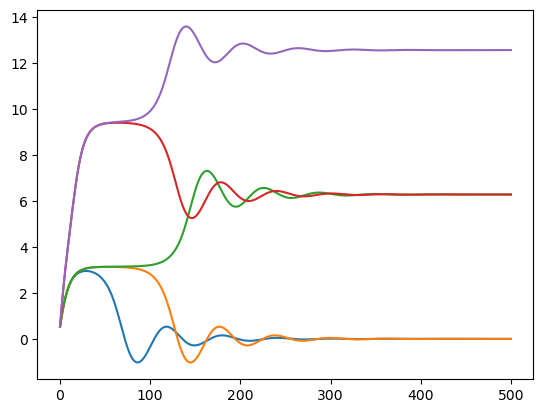

In [70]:
plt.plot(y_true[0,:],label="limit")
plt.plot(y_err[0,:],label="1 tour lim")
plt.plot(y_err2[0,:],label="2 tours")
plt.plot(y_err3[0,:],label="3 tours")
plt.plot(y_err4[0,:],label="4 tours")
#plt.hlines(np.pi,0,len(y_true[0,:]))

Identifying max angle of trajectory as first index when p changes sign 

62 3.12836 3.1429496


(Array(3.127401, dtype=float32), Array(3.1433108, dtype=float32))

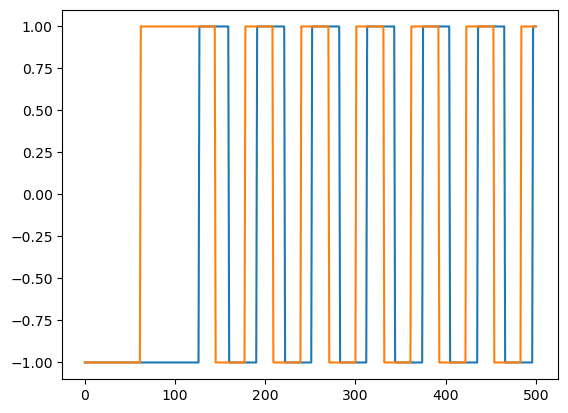

In [103]:
plt.plot(np.sign(F(y_err,0))[1,:])
plt.plot(np.sign(F(y_err2,0))[1,:])
index_lim = np.where(np.sign(F(y_err,0))[1,:] - np.sign(F(y_err2,0))[1,:] != 0)[0][0]
print(index_lim, y_err[0,index_lim], y_err2[0,index_lim])
y_err[0,index_lim+1], y_err2[0,index_lim+1]

[2.9824708  0.10021485] [2.9829738  0.10042825] [ 0.10021485 -0.06348328] [ 0.10042825 -0.06338978]
[9.286546   0.08546306] [9.291883   0.08754517] [ 0.08546306 -0.05486918] [ 0.08754517 -0.05383567]


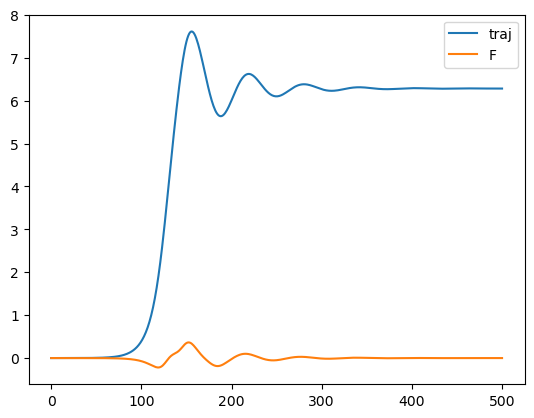

In [97]:
# find values of p when q = pi
plt.plot(np.abs(y_err[0,:]-y_err2[0,:]),label="traj")
epsilon0 = np.abs(np.mean(y_err[:,0]- y_err2[:,0]))
error = np.abs(y_err[0,:]- y_err2[0,:])
index_lim = np.where(error > 10*epsilon0)[0][0]
print(y_err[:,index_lim], y_err2[:,index_lim], F(y_err[:,index_lim],0), F(y_err2[:,index_lim],0))
plt.legend()

epsilon1 = np.abs(np.mean(y_err3[:,0]- y_err4[:,0]))
error = np.abs(y_err3[0,:]- y_err4[0,:])
index_lim = np.where(error > 10*epsilon1)[0][0]
print(y_err3[:,index_lim], y_err4[:,index_lim], F(y_err3[:,index_lim],0), F(y_err4[:,index_lim],0))

In [104]:
# load model 
import json 
from networks import *
import jax
import equinox as eqx
from datasets import *
import os
from forecasters import *

path = 'data/sanity_checks2'
dataset_name = 'pendulum'
train, _, test = init_dataloaders("pendulum", 'RK4', os.path.join(path, dataset_name))

def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method):
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=test.dataset.dt,
                num_steps=test.dataset.num_steps,
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op

Model ParamODE($\omega_0$)+MLP - APHYNITY loss

In [105]:
exp_name = 'incomplete_aug_34_lx8y2wmb'
model_name = 'model_4.318e-03.eqx'
data_path = 'data/sanity_checks2'
model_phy_option = 'incomplete'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
model, _lambda, min_op = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method)
model

data/sanity_checks2/incomplete_aug_34_lx8y2wmb/model_4.318e-03.eqx
l2


Forecaster(
  model_phy=PendulumParamPDE(omega0_square=f32[], alpha=0.0, is_damped=False),
  model_aug=MLP(
    layers=[
      Linear(
        weight=f32[200,2],
        bias=f32[200],
        in_features=2,
        out_features=200,
        use_bias=True
      ),
      <wrapped function relu>,
      Linear(
        weight=f32[200,200],
        bias=f32[200],
        in_features=200,
        out_features=200,
        use_bias=True
      ),
      <wrapped function relu>,
      Linear(
        weight=f32[2,200],
        bias=f32[2],
        in_features=200,
        out_features=2,
        use_bias=True
      )
    ]
  ),
  dt=0.5,
  num_steps=40,
  integration_method='RK4',
  is_phy='incomplete',
  is_augmented=True,
  int_=<function RK_solver_fixed>
)

Model ParamODE($\omega_0$)+MLP - trajectory loss

In [106]:
exp_name = 'incomplete_no_Fa_aug_36_h3ohcim6'
model_name = 'model_5.693e-03.eqx'
data_path = 'data/sanity_checks2'
model_phy_option = 'incomplete_no_Fa'
model_aug_option = True
dataset_name = 'pendulum'
model_nofa, _,_ = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method)
F_nofa = model_nofa.derivative_estimator
F_nofa

data/sanity_checks2/incomplete_no_Fa_aug_36_h3ohcim6/model_5.693e-03.eqx
l2


BoundMethod(
  __func__=<function derivative_estimator>,
  __self__=Forecaster(
    model_phy=PendulumParamPDE(omega0_square=f32[], alpha=0.0, is_damped=False),
    model_aug=MLP(
      layers=[
        Linear(
          weight=f32[200,2],
          bias=f32[200],
          in_features=2,
          out_features=200,
          use_bias=True
        ),
        <wrapped function relu>,
        Linear(
          weight=f32[200,200],
          bias=f32[200],
          in_features=200,
          out_features=200,
          use_bias=True
        ),
        <wrapped function relu>,
        Linear(
          weight=f32[2,200],
          bias=f32[2],
          in_features=200,
          out_features=2,
          use_bias=True
        )
      ]
    ),
    dt=0.5,
    num_steps=40,
    integration_method='RK4',
    is_phy='incomplete_no_Fa',
    is_augmented=True,
    int_=<function RK_solver_fixed>
  )
)

In [122]:
y0

array([0.528, 1.329])

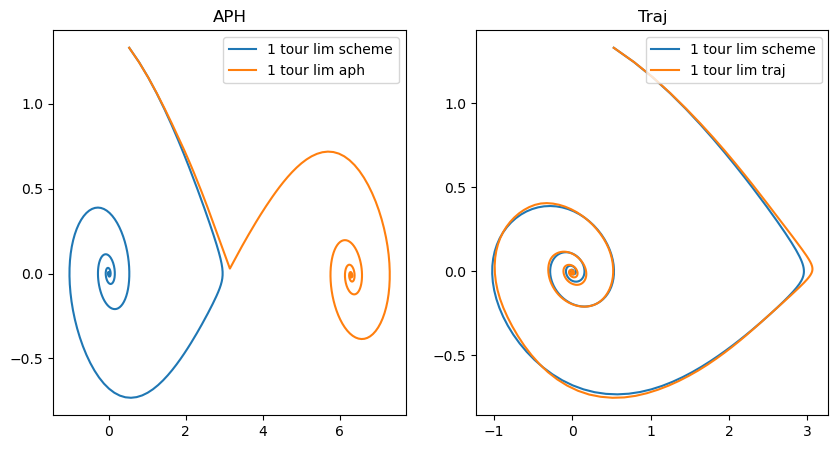

In [134]:
# 1 tour lim
y0_err_model = jnp.array([0.528,1.3293])
y_scheme,_,_,_ = RK_solver_fixed(F,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
aph_err,_,_,_ = RK_solver_fixed(model.derivative_estimator,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
traj_err,_,_,_ = RK_solver_fixed(F_nofa,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)

fig, ax = plt.subplots(1,2, figsize=(10,5))
#ax[0].plot(y_err[0,:],y_err[1,:],label="1 tour lim", color='black')
ax[0].plot(y_scheme[0,:],y_scheme[1,:],label="1 tour lim scheme")
ax[0].plot(aph_err[0,:],aph_err[1,:],label="1 tour lim aph")
ax[0].legend()
ax[0].set_title("APH")

ax[1].plot(y_scheme[0,:],y_scheme[1,:],label="1 tour lim scheme")
#ax[1].plot(y_err[0,:],y_err[1,:],label="1 tour lim", color='black')
ax[1].plot(traj_err[0,:],traj_err[1,:],label="1 tour lim traj")
ax[1].legend()
ax[1].set_title("Traj")
ax[0].legend()



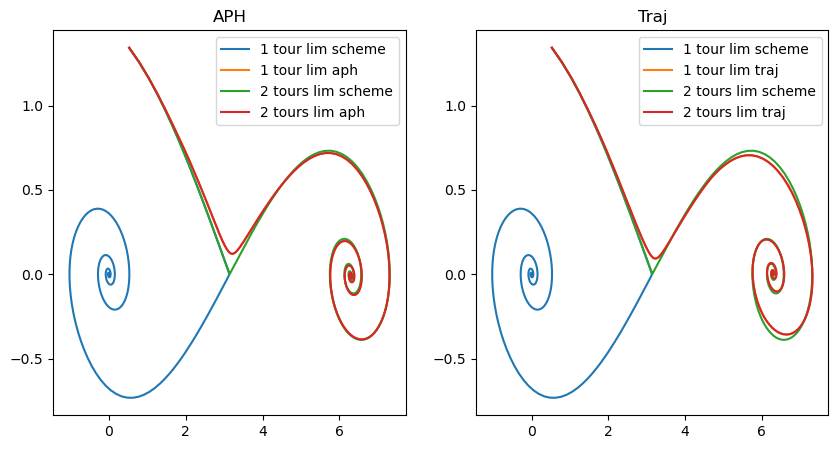

In [139]:
# 2 tour lim
y0_err_model = y0_err
y0_err_model2 = y0_err2
y_scheme,_,_,_ = RK_solver_fixed(F,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
aph_err,_,_,_ = RK_solver_fixed(model.derivative_estimator,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
traj_err,_,_,_ = RK_solver_fixed(F_nofa,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)

y_scheme2,_,_,_ = RK_solver_fixed(F,y0_err_model2,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
aph_err2,_,_,_ = RK_solver_fixed(model.derivative_estimator,y0_err_model2,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
traj_err2,_,_,_ = RK_solver_fixed(F_nofa,y0_err_model2,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)


fig, ax = plt.subplots(1,2, figsize=(10,5))
#ax[0].plot(y_err[0,:],y_err[1,:],label="1 tour lim", color='black')
ax[0].plot(y_scheme[0,:],y_scheme[1,:],label="1 tour lim scheme")
ax[0].plot(aph_err[0,:],aph_err[1,:],label="1 tour lim aph")
ax[0].plot(y_scheme2[0,:],y_scheme2[1,:],label="2 tours lim scheme")
ax[0].plot(aph_err2[0,:],aph_err2[1,:],label="2 tours lim aph")
ax[0].legend()
ax[0].set_title("APH")

ax[1].plot(y_scheme[0,:],y_scheme[1,:],label="1 tour lim scheme")
#ax[1].plot(y_err[0,:],y_err[1,:],label="1 tour lim", color='black')
ax[1].plot(traj_err[0,:],traj_err[1,:],label="1 tour lim traj")
ax[1].plot(y_scheme2[0,:],y_scheme2[1,:],label="2 tours lim scheme")
ax[1].plot(traj_err2[0,:],traj_err2[1,:],label="2 tours lim traj")
ax[1].legend()
ax[1].set_title("Traj")
ax[0].legend()



Les 2 modèles font déjà faire un tour pour le point limite du système réel: [0.528 , 1.3423]. 


In [141]:
y0_err4

array([0.528, 2.523])

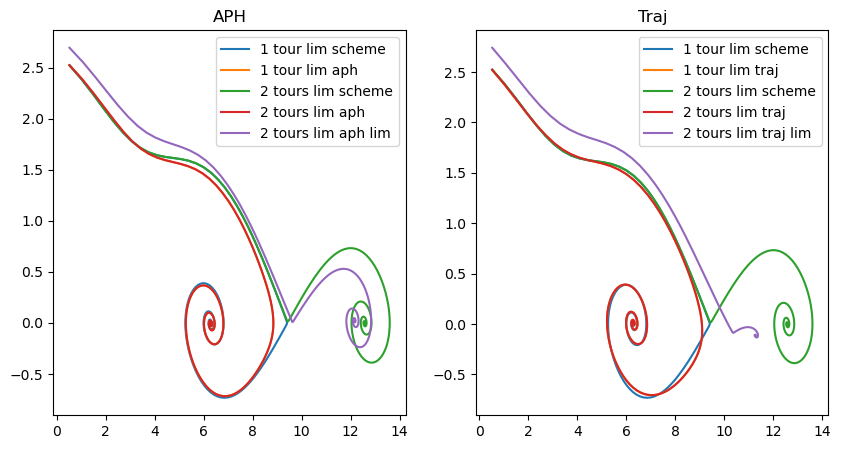

In [179]:
# 2 tour lim
y0_err_model = y0_err3
y0_err_model2 = y0_err4
y0_lim_aph = np.array([0.528,2.694])
y0_lim_traj = np.array([0.528,2.741])
y_scheme,_,_,_ = RK_solver_fixed(F,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
aph_err,_,_,_ = RK_solver_fixed(model.derivative_estimator,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
traj_err,_,_,_ = RK_solver_fixed(F_nofa,y0_err_model,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)

aph_err_lim,_,_,_ = RK_solver_fixed(model.derivative_estimator,y0_lim_aph,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
traj_err_lim,_,_,_ = RK_solver_fixed(F_nofa,y0_lim_traj,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)

y_scheme2,_,_,_ = RK_solver_fixed(F,y0_err_model2,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
aph_err2,_,_,_ = RK_solver_fixed(model.derivative_estimator,y0_err_model2,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)
traj_err2,_,_,_ = RK_solver_fixed(F_nofa,y0_err_model2,dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"]) #y(T)


fig, ax = plt.subplots(1,2, figsize=(10,5))
#ax[0].plot(y_err[0,:],y_err[1,:],label="1 tour lim", color='black')
ax[0].plot(y_scheme[0,:],y_scheme[1,:],label="1 tour lim scheme")
ax[0].plot(aph_err[0,:],aph_err[1,:],label="1 tour lim aph")
ax[0].plot(y_scheme2[0,:],y_scheme2[1,:],label="2 tours lim scheme")
ax[0].plot(aph_err2[0,:],aph_err2[1,:],label="2 tours lim aph")
ax[0].plot(aph_err_lim[0,:],aph_err_lim[1,:],label="2 tours lim aph lim")
ax[0].legend()
ax[0].set_title("APH")

ax[1].plot(y_scheme[0,:],y_scheme[1,:],label="1 tour lim scheme")
#ax[1].plot(y_err[0,:],y_err[1,:],label="1 tour lim", color='black')
ax[1].plot(traj_err[0,:],traj_err[1,:],label="1 tour lim traj")
ax[1].plot(y_scheme2[0,:],y_scheme2[1,:],label="2 tours lim scheme")
ax[1].plot(traj_err2[0,:],traj_err2[1,:],label="2 tours lim traj")
ax[1].plot(traj_err_lim[0,:],traj_err_lim[1,:],label="2 tours lim traj lim")
ax[1].legend()
ax[1].set_title("Traj")
ax[0].legend()



Pour les points limit et tipping du système réel, les modèles ne font pas faire le 2e tour: [0.528, 2.522], [0.528, 2.523].
APH réalise un tour réaliste pour [0.528,2.694], traj réalise un tour moins réaliste à partir de [0.528,2.741]. 

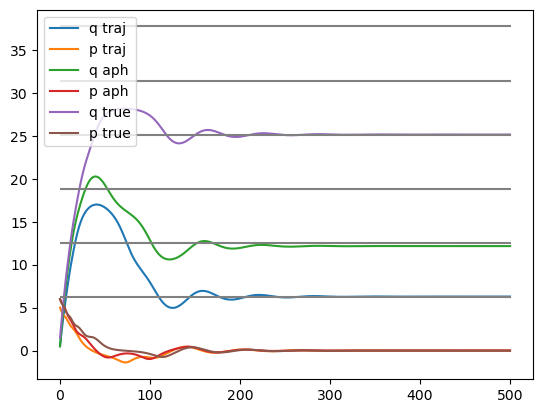

In [217]:
y0_phys = jnp.array([0.528,5]) # jnp.array([0.528,3.735]
y_true_phys,_,_,_ = RK_solver_fixed(F, jnp.array([1.5,6]), dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"])
y_traj_phys, _,_,_ = RK_solver_fixed(F_nofa, y0_phys, dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"])
y_aph_phys,_,_,_ = RK_solver_fixed(model.derivative_estimator, jnp.array([0.5,6]), dt_inf, int((t1 - t0) / dt_inf),RK_tableaux["RK4"])
plt.plot(y_traj_phys[0,:], label="q traj")
plt.plot(y_traj_phys[1,:], label = "p traj")
plt.plot(y_aph_phys[0,:], label = 'q aph')
plt.plot(y_aph_phys[1,:], label="p aph")
plt.plot(y_true_phys[0,:], label="q true")
plt.plot(y_true_phys[1,:], label="p true")
for k in range(1,7):
    plt.hlines(k*2*np.pi,0,len(y_true_phys[0,:]), color="grey")
plt.legend()

p both goes to zero. q Aph does not always reach a true zero, whereas q traj seems to. traj and aph can produce unrealistic scenarios (fait 2 tours dans un sens puis un dans l'autre) -> trop de vitesse p 



Tests:
- vérifier qu'on tend vers un vrai zéro dans les simulations (régime de p): a partir de quelle vitesse initiale ca ne fonctionne plus 
- situations irréalistes (tours dans l'autre sens) en fonction de p aussi: critere avec erreur sur etat final sur q (même q ?) + a partir de quelle vitesse initiale on se trompe, sous quel seuil on passe qui entraine ce non-sens. 
avec points de départ 0.5, 1.5 ? 

## Automated tests at infinity: stationarity and robustness
Infinity=400s 

In [ ]:
limit_points_real = np.array(
    [
        [0.528,1.3423],
        [0.528,2.522],
        [-0.528,-1.3423],
        [-0.528,-2.522]
        ]
        )
tipping_points_real = np.array(
    [
        [0.528,1.3424],
        [0.528,2.523],
        [-0.528,-1.3424],
        [-0.528,-1.3424]
        ])



In [ ]:
path_sc2_bis = "/Users/mayajanvier/jax-phynity/data/lipschitz/incomplete_aug_20_srefavep/model_4.321e-04.json"
path_sc22_bis = "/Users/mayajanvier/jax-phynity/data/lipschitz/incomplete_no_Fa_aug_20_ps3fe9eb/model_4.466e-03.json"
path_sc3_bis = "/Users/mayajanvier/jax-phynity/data/lipschitz/none_aug_19_yt8wqw57/model_3.270e-02.json"


In [218]:
# load model 
import json 
from networks import *
import jax
import equinox as eqx
from datasets import *
import os
from forecasters import *

path = 'data/lipschitz'
dataset_name = 'pendulum'
train, _, test = init_dataloaders("pendulum", 'RK4', os.path.join(path, dataset_name))

def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method):
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=test.dataset.dt,
                num_steps=test.dataset.num_steps,
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op

In [219]:
model_aph = load_model(path, "model_4.321e-04.eqx", "incomplete_aug_20_srefavep", "incomplete", True, "RK4")
model_traj = load_model(path, "model_4.466e-03.eqx", "incomplete_no_Fa_aug_20_ps3fe9eb", "incomplete_no_Fa", True, "RK4")
model_none = load_model(path, "model_3.270e-02.eqx", "none_aug_19_yt8wqw57", "none", True, "RK4")

data/lipschitz/incomplete_aug_20_srefavep/model_4.321e-04.eqx
l2
data/lipschitz/incomplete_no_Fa_aug_20_ps3fe9eb/model_4.466e-03.eqx
l2
data/lipschitz/none_aug_19_yt8wqw57/model_3.270e-02.eqx
none


In [220]:
F_aph = model_aph[0].derivative_estimator
F_traj = model_traj[0].derivative_estimator
F_none = model_none[0].derivative_estimator

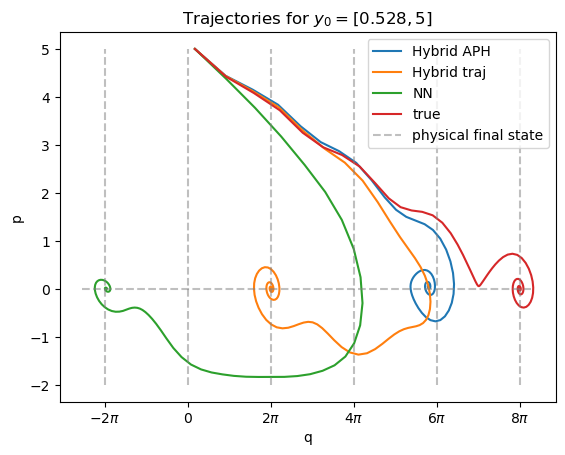

In [415]:
dt = 0.5 # dt train
t0 = 0
t1 = 200
y0 = np.array([0.528,1.329]) # traj limite
y02 = jnp.array([0.528,5]) 
y_aph = RK_solver_fixed(F_aph,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_traj = RK_solver_fixed(F_traj,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_none = RK_solver_fixed(F_none,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_true = RK_solver_fixed(F,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
plt.plot(y_aph[0,:],y_aph[1,:],label="Hybrid APH")
plt.plot(y_traj[0,:],y_traj[1,:],label="Hybrid traj")
plt.plot(y_none[0,:],y_none[1,:],label="NN")
plt.plot(y_true[0,:],y_true[1,:],label="true")
plt.hlines(0,-8 ,26,  color="grey", alpha=0.5, linestyle="--")
plt.vlines([-2*np.pi,0,2*np.pi, 4*np.pi, 6*np.pi,8*np.pi], -2, 5, color="grey", alpha=0.5, linestyle="--", label="physical final state")
plt.xticks([-2*np.pi,0,2*np.pi, 4*np.pi, 6*np.pi,8*np.pi], [r"$-2\pi$",r"$0$",r"$2\pi$",r"$4\pi$",r"$6\pi$",r"$8\pi$"])
plt.xlabel("q")
plt.ylabel("p")
plt.title(r"Trajectories for $y_0 = [0.528,5]$")
plt.legend()

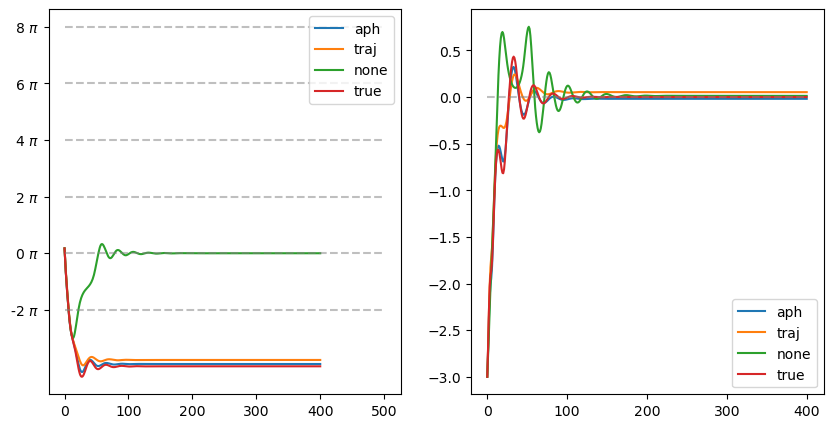

In [240]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(y_aph[0,:],label="aph")
ax[0].plot(y_traj[0,:],label="traj")
ax[0].plot(y_none[0,:],label="none")
ax[0].plot(y_true[0,:],label="true")
for k in range(-1,5):
    ax[0].hlines(k*2*np.pi,0,len(y_true_phys[0,:]), color="grey", alpha=0.5, linestyle="--")
ax[0].set_yticks(np.arange(-2*np.pi, 10*np.pi, 2*np.pi), labels=[fr"{k} $\pi$" for k in range(-2, 10, 2)])
ax[0].legend()

ax[1].plot(y_aph[1,:],label="aph")
ax[1].plot(y_traj[1,:],label="traj")
ax[1].plot(y_none[1,:],label="none")
ax[1].plot(y_true[1,:],label="true")
ax[1].hlines(0, 0, len(y_true[1,:]), color="grey", alpha=0.5, linestyle="--")
ax[1].legend()

question de la généralisation: quand on donne des p hors de la zone d'entrainement, MLP se sent obligé de revenir dans les zones explorées (0 ou -2pi, 2-pi), pas d'exemples de 2 tours dans le jeu d'entrainement 

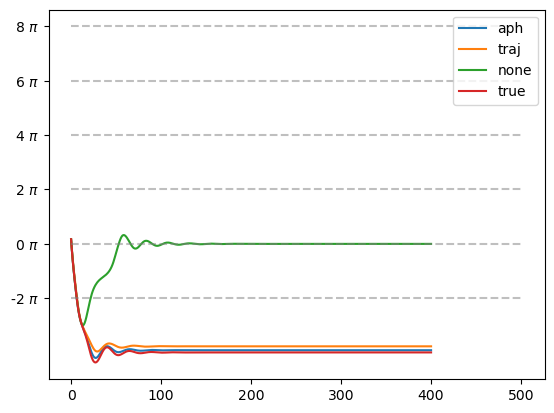

In [236]:
y02 = jnp.array([0.528,-3]) 
y_aph = RK_solver_fixed(F_aph,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_traj = RK_solver_fixed(F_traj,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_none = RK_solver_fixed(F_none,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_true = RK_solver_fixed(F,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
plt.plot(y_aph[0,:],label="aph")
plt.plot(y_traj[0,:],label="traj")
plt.plot(y_none[0,:],label="none")
plt.plot(y_true[0,:],label="true")
for k in range(-1,5):
    plt.hlines(k*2*np.pi,0,len(y_true_phys[0,:]), color="grey", alpha=0.5, linestyle="--")
plt.yticks(np.arange(-2*np.pi, 10*np.pi, 2*np.pi), labels=[fr"{k} $\pi$" for k in range(-2, 10, 2)])
plt.legend()

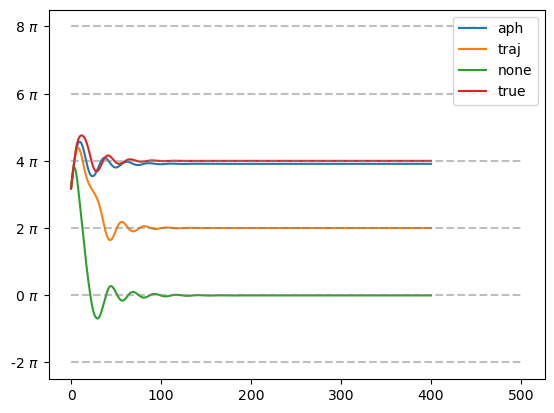

In [241]:
y02 = jnp.array([10,1.5]) 
y_aph = RK_solver_fixed(F_aph,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_traj = RK_solver_fixed(F_traj,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_none = RK_solver_fixed(F_none,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
y_true = RK_solver_fixed(F,y02,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
plt.plot(y_aph[0,:],label="aph")
plt.plot(y_traj[0,:],label="traj")
plt.plot(y_none[0,:],label="none")
plt.plot(y_true[0,:],label="true")
for k in range(-1,5):
    plt.hlines(k*2*np.pi,0,len(y_true_phys[0,:]), color="grey", alpha=0.5, linestyle="--")
plt.yticks(np.arange(-2*np.pi, 10*np.pi, 2*np.pi), labels=[fr"{k} $\pi$" for k in range(-2, 10, 2)])
plt.legend()

### Design of test points: 4 regions
- q_in, p_in
- q_out, p_in
- q_in, p_out
- q_out, p_out

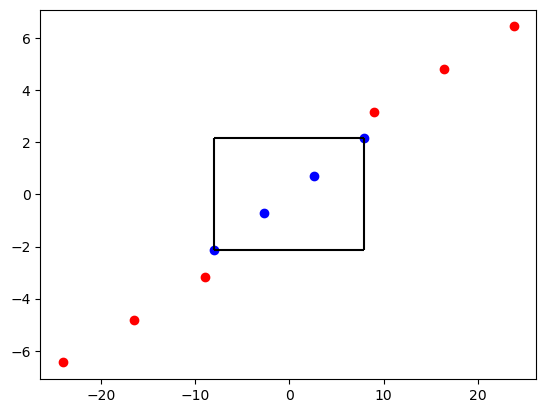

In [259]:
# training ranges
p_min,p_max = -2.15, 2.15
q_min, q_max = -8.03, 7.94
factor=3
q_left = np.linspace(factor*q_min, q_min-1, 3)
q_right = np.linspace(q_max+1, factor*q_max, 3)
q_in = np.linspace(q_min, q_max, 4)
q_out = np.concatenate((q_left, q_right))
p_in = np.linspace(p_min, p_max, 4)
p_left = np.linspace(factor*p_min, p_min-1, 3)
p_right = np.linspace(p_max+1, factor*p_max, 3)
p_out = np.concatenate((p_left, p_right))
q_out, p_out

plt.scatter(q_in, p_in, color="blue")
plt.scatter(q_out, p_out, color="red")
# plot box 
plt.hlines(p_min, q_min, q_max, color="black")
plt.hlines(p_max, q_min, q_max, color="black")
plt.vlines(q_min, p_min, p_max, color="black")
plt.vlines(q_max, p_min, p_max, color="black")


In [262]:
import itertools
y0_in = np.array(list(itertools.product(q_in, p_in)))
y0_out = np.array(list(itertools.product(q_out, p_out)))
y0_q_in = np.array(list(itertools.product(q_in, p_out)))
y0_p_in = np.array(list(itertools.product(q_out, p_in)))

Text(0.5, 1.0, 'Initial conditions')

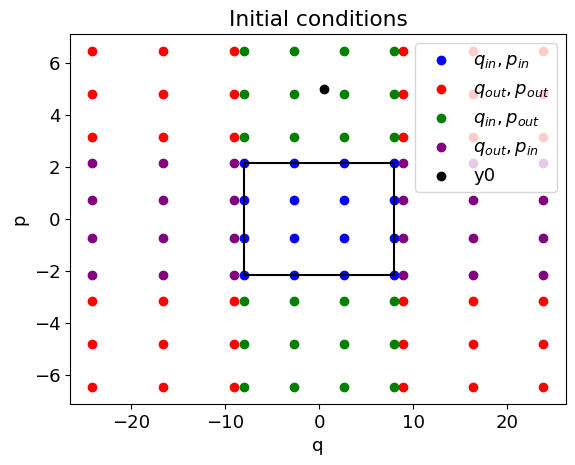

In [458]:
# plot box 
plt.hlines(p_min, q_min, q_max, color="black")
plt.hlines(p_max, q_min, q_max, color="black")
plt.vlines(q_min, p_min, p_max, color="black")
plt.vlines(q_max, p_min, p_max, color="black")
# plot points
plt.scatter(y0_in[:,0], y0_in[:,1], color="blue", label=r"$q_{in}, p_{in}$")
plt.scatter(y0_out[:,0], y0_out[:,1], color="red", label=r"$q_{out}, p_{out}$")
plt.scatter(y0_q_in[:,0], y0_q_in[:,1], color="green", label=r"$q_{in}, p_{out}$")
plt.scatter(y0_p_in[:,0], y0_p_in[:,1], color="purple", label=r"$q_{out}, p_{in}$")
plt.scatter(0.528, 5, color="black", label="y0")
plt.legend()
plt.xlabel("q")
plt.ylabel("p")
plt.title("Initial conditions")


### Generate trajectories and metrics

In [273]:
# generate trajectories and all metrics
import pandas as pd 

def compute_trajectories(F_model, y0_list, dt=0.5, t1=400):
    y_true_list = []
    y_pred_list = []
    dico = {}
    for i, y0 in enumerate(y0_list):
        y_true = RK_solver_fixed(F,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
        y_pred = RK_solver_fixed(F_model,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK4"])[0] #y(T)
        y_true_list.append(y_true)
        y_pred_list.append(y_pred)
        dico[i] = {
            "y0":y0,
            "y_true":y_true,
            "y_pred":y_pred,
            }
    return pd.DataFrame(dico).T

truth_SC = compute_trajectories(F, y0_in, dt=0.5, t1=400)

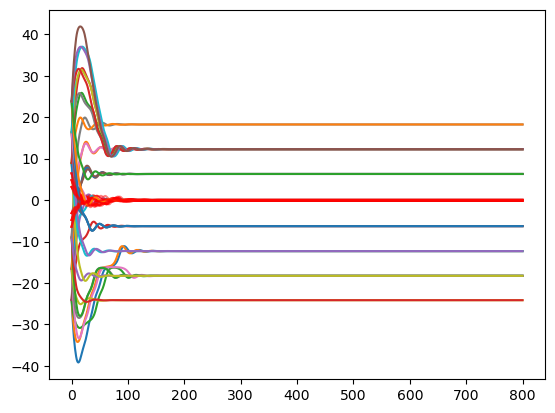

In [281]:
aph_out = compute_trajectories(F_aph, y0_out, dt=0.5, t1=400)
for i in range(aph_out.shape[0]):
    plt.plot(aph_out.iloc[i]["y_pred"][0,:])
    plt.plot(aph_out.iloc[i]["y_pred"][1,:], color="red", alpha=0.5)

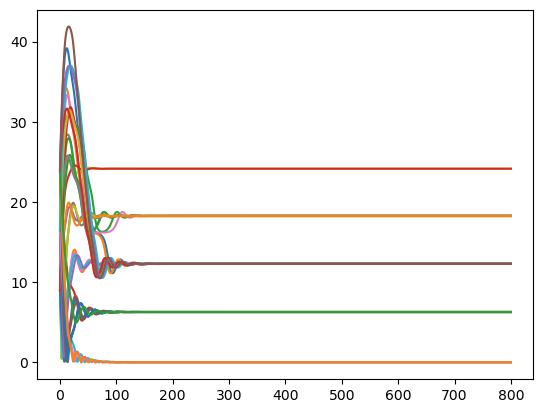

In [316]:
aph_out = compute_trajectories(F_aph, y0_out, dt=0.5, t1=400)
for i in range(aph_out.shape[0]):
    plt.plot(np.abs(aph_out.iloc[i]["y_pred"][0,:]))
    #plt.plot(aph_out.iloc[i]["y_pred"][1,:], color="red", alpha=0.5)

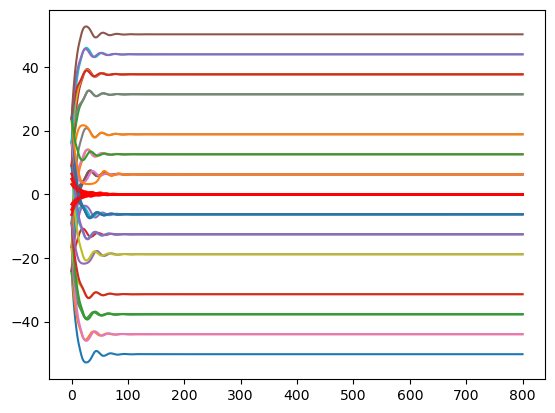

In [313]:
for i in range(aph_out.shape[0]):
    plt.plot(aph_out.iloc[i]["y_true"][0,:])
    plt.plot(aph_out.iloc[i]["y_true"][1,:], color="red", alpha=0.5)

In [280]:
truth_SC.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
dtype: float32

In [340]:
def compute_metrics(data):
    #data = compute_trajectories(F_model, y0_list, dt=0.5, t1=400)
    data["L1"] = data.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
    data["p_inf_true"] = data.apply(lambda x: x["y_true"][1,-1:], axis=1)
    data["p_inf_pred"] = data.apply(lambda x: x["y_pred"][1,-1:], axis=1)
    data["q_inf_true"] = data.apply(lambda x: x["y_true"][0,-1:], axis=1)
    data["q_inf_pred"] = data.apply(lambda x: x["y_pred"][0,-1:], axis=1)
    data["p_inf_pred_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_pred"][1,-200:])), axis=1)
    data["p_inf_true_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_true"][1,-200:])), axis=1)
    data["q_inf_pred_mean"] = data.apply(lambda x: np.mean(x["y_pred"][0,-200:]), axis=1)
    data["q_inf_true_mean"] = data.apply(lambda x: np.mean(x["y_true"][0,-200:]), axis=1)

    # "max" is where p changes sign for the first time
    p_lim_true = data.apply(lambda x: np.where(np.sign(x["y_true"][1,:-1]) - np.sign(x["y_true"][1,1:]) != 0)[0][0], axis=1)
    p_lim_pred = data.apply(lambda x: np.where(np.sign(x["y_pred"][1,:-1]) - np.sign(x["y_pred"][1,1:]) != 0)[0][0], axis=1)
    data["p_lim_true"] = p_lim_true
    data["p_lim_pred"] = p_lim_pred
    print(p_lim_true.max(), p_lim_pred.max())
    data["q_max_pred"] = data.apply(lambda x: x["y_pred"][0,x["p_lim_pred"]], axis=1)
    data["q_max_true"] = data.apply(lambda x: x["y_true"][0,x["p_lim_true"]], axis=1)
    #data["q_max_pred"] = data.apply(lambda x: np.max(np.abs(x["y_pred"][0,1:])), axis=1)
    #data["q_max_true"] = data.apply(lambda x: np.max(np.abs(x["y_true"][0,1:])), axis=1)
    data["q_inf_modulo2pi_pred"] = data.apply(lambda x: min(np.abs(x["q_inf_pred"]%(2*np.pi)), np.abs(x["q_inf_pred"]%(-2*np.pi))), axis=1)
    data["q_inf_modulo2pi_true"] = data.apply(lambda x: min(np.abs(x["q_inf_true"]%(2*np.pi)), np.abs(x["q_inf_true"]%(-2*np.pi))), axis=1)
    data["pred_isphysical"] = np.abs(data["q_inf_pred"]-data["q_max_pred"]) < np.pi
    data["true_isphysical"] = np.abs(data["q_inf_true"]-data["q_max_true"]) < np.pi
    return data

aph_data_out = compute_metrics(aph_out)
aph_data_out



33 39


,y0,y_true,y_pred,L1,p_inf_true,p_inf_pred,q_inf_true,q_inf_pred,p_inf_pred_mean,p_inf_true_mean,q_inf_pred_mean,q_inf_true_mean,q_max_pred,q_max_true,q_inf_modulo2pi_pred,q_inf_modulo2pi_true,pred_isphysical,true_isphysical,p_lim_true,p_lim_pred
0,"[-24.089999999999996, -6.449999999999999]","[[-24.09, -27.158346, -29.909086, -32.431534, ...","[[-24.09, -26.908293, -29.312803, -31.408367, ...",18.274506,[-3.3117074e-06],[-0.019244615],[-50.26548],[-12.31046],0.019245,3.311707e-06,-12.31046,-50.265476,-39.17396,-52.854576,[0.25591087],[3.8146973e-06],False,True,25,12
1,"[-24.089999999999996, -4.8]","[[-24.09, -26.380907, -28.412975, -30.25851, -...","[[-24.09, -26.179178, -27.939512, -29.424, -30...",15.290520,[3.6386348e-06],[-0.019244617],[-43.9823],[-12.31046],0.019245,3.638635e-06,-12.31046,-43.9823,-34.222363,-45.714806,[0.25591087],[1.4305115e-06],False,True,24,11
2,"[-24.089999999999996, -3.15]","[[-24.09, -25.604263, -26.949564, -28.11137, -...","[[-24.09, -25.454676, -26.59755, -27.501802, -...",9.394517,[1.3077089e-07],[-0.059564646],[-37.699112],[-18.27445],0.059565,1.307709e-07,-18.27445,-37.699112,-30.79555,-38.910004,[0.57510614],[9.536743e-07],False,True,25,16
3,"[-24.089999999999996, 3.15]","[[-24.09, -22.622362, -21.327202, -20.119848, ...","[[-24.09, -22.543997, -21.14921, -19.828232, -...",3.073840,[-8.2792684e-07],[0.0015039217],[-12.56637],[-6.28436],0.001504,8.279267e-07,-6.2843604,-12.566369,-5.210333,-10.83111,[0.0011744499],[9.536743e-07],True,True,19,39
4,"[-24.089999999999996, 4.8]","[[-24.09, -21.833786, -19.785055, -17.894651, ...","[[-24.09, -21.779737, -19.657207, -17.686281, ...",3.084852,[2.3967436e-07],[-0.012266755],[-6.2831855],[0.022777516],0.012267,2.396744e-07,0.022777516,-6.2831855,1.356318,-3.6043613,[0.022777516],[0.0],True,True,23,30
5,"[-24.089999999999996, 6.449999999999999]","[[-24.09, -21.042742, -18.261673, -15.764702, ...","[[-24.09, -21.01961, -18.182535, -15.594421, -...",0.066956,[-2.3967436e-07],[-0.011755499],[6.2831855],[6.2952967],0.011756,2.396744e-07,6.2952967,6.2831855,8.286425,7.4764757,[0.012111187],[0.0],True,True,33,27
6,"[-16.56, -6.449999999999999]","[[-16.56, -19.652452, -22.42966, -24.957653, -...","[[-16.56, -19.415758, -21.923725, -24.105186, ...",12.614594,[3.6386348e-06],[-0.059568077],[-43.9823],[-18.274445],0.059568,3.638635e-06,-18.274445,-43.9823,-33.350655,-46.05415,[0.57511187],[1.4305115e-06],False,True,25,13
7,"[-16.56, -4.8]","[[-16.56, -18.872232, -20.962843, -22.814762, ...","[[-16.56, -18.704178, -20.583893, -22.170334, ...",9.547814,[1.3077089e-07],[-0.059568077],[-37.699112],[-18.274445],0.059568,1.307709e-07,-18.274445,-37.699112,-28.409142,-39.17063,[0.57511187],[9.536743e-07],False,True,26,14
8,"[-16.56, -3.15]","[[-16.56, -18.089231, -19.509827, -20.760954, ...","[[-16.56, -17.978584, -19.248535, -20.32424, -...",3.637059,[1.8520101e-06],[-0.108628914],[-31.415928],[-24.151054],0.108629,1.852010e-06,-24.151054,-31.415928,-25.082909,-32.506393,[0.98168755],[4.7683716e-07],True,True,29,17
9,"[-16.56, 3.15]","[[-16.56, -15.071578, -13.692003, -12.393485, ...","[[-16.56, -15.044587, -13.631415, -12.298686, ...",3.086507,[2.3967436e-07],[-0.012266755],[-6.2831855],[0.022777516],0.012267,2.396744e-07,0.022777516,-6.2831855,1.0364183,-3.8019485,[0.022777516],[0.0],True,True,18,36


In [341]:
aph_data_pin = compute_metrics(compute_trajectories(F_aph, y0_p_in, dt=0.5, t1=400))
aph_data_qin = compute_metrics(compute_trajectories(F_aph, y0_q_in, dt=0.5, t1=400))

28 36
39 35


In [344]:
aph_data_in = compute_metrics(compute_trajectories(F_aph, y0_in, dt=0.5, t1=400))

25 28


In [379]:
def analysis(data, exp):
    print (f"Analysis of {exp}")
    print(f"Mean L1 error: {data['L1'].mean()}")
    # mean of p_inf over 100 last s
    print(f"p_inf_true_mean over 100 last s: {data['p_inf_true_mean'].mean()}")
    print(f"p_inf_pred_mean over 100 last s: {data['p_inf_pred_mean'].mean()}")
    # q_inf modulo 2pi
    print(f"q_inf_modulo2pi_true: {data['q_inf_modulo2pi_true'].mean()}")
    print(f"q_inf_modulo2pi_pred: {data['q_inf_modulo2pi_pred'].mean()}")
    # physicality
    print(f"Number of physical trajectories pred: {data['pred_isphysical'].sum()}")
    print(f"Number of physical trajectories true: {data['true_isphysical'].sum()}")

    categories = ['L1', 'p_inf_pred_mean', 'q_inf_modulo2pi_pred', 'pred_isphysical']
    data_out = {}
    data_out["L1"] = data["L1"].mean()
    data_out["p_inf_mean"] = (data["p_inf_pred_mean"]).mean()
    data_out["q_inf_modulo2pi"] = (data["q_inf_modulo2pi_pred"]).mean()
    data_out["physicality"] = (data["pred_isphysical"].sum()/data["true_isphysical"].sum())
    return data_out


In [380]:
aph_in = analysis(aph_data_in, "aph_in")
aph_in

Analysis of aph_in
Mean L1 error: 0.05180185288190842
p_inf_true_mean over 100 last s: 3.2681884931662353e-07
p_inf_pred_mean over 100 last s: 0.011268979869782925
q_inf_modulo2pi_true: [2.3841858e-07]
q_inf_modulo2pi_pred: [0.07570468]
Number of physical trajectories pred: 16
Number of physical trajectories true: 16


{'L1': 0.051801853,
 'p_inf_mean': 0.01126898,
 'q_inf_modulo2pi': array([0.07570468], dtype=float32),
 'physicality': 1.0}

In [381]:
aph_out = analysis(aph_data_out, "aph_out")

Analysis of aph_out
Mean L1 error: 5.7323150634765625
p_inf_true_mean over 100 last s: 8.800030286693072e-07
p_inf_pred_mean over 100 last s: 0.029461301863193512
q_inf_modulo2pi_true: [7.549922e-07]
q_inf_modulo2pi_pred: [0.2939922]
Number of physical trajectories pred: 22
Number of physical trajectories true: 36


In [385]:
aph_pin = analysis(aph_data_pin, "aph_pin")
aph_qin =analysis(aph_data_qin, "aph_qin")

Analysis of aph_pin
Mean L1 error: 2.122912645339966
p_inf_true_mean over 100 last s: 5.810263701278018e-07
p_inf_pred_mean over 100 last s: 0.031587790697813034
q_inf_modulo2pi_true: [2.9802322e-07]
q_inf_modulo2pi_pred: [0.33497536]
Number of physical trajectories pred: 21
Number of physical trajectories true: 24
Analysis of aph_qin
Mean L1 error: 2.7821731567382812
p_inf_true_mean over 100 last s: 6.863395469736133e-07
p_inf_pred_mean over 100 last s: 0.04117049649357796
q_inf_modulo2pi_true: [4.172325e-07]
q_inf_modulo2pi_pred: [0.4448236]
Number of physical trajectories pred: 17
Number of physical trajectories true: 24


In [346]:
no_fa_data_in = compute_metrics(compute_trajectories(F_traj, y0_in, dt=0.5, t1=400))
no_fa_data_out = compute_metrics(compute_trajectories(F_traj, y0_out, dt=0.5, t1=400))
no_fa_data_pin = compute_metrics(compute_trajectories(F_traj, y0_p_in, dt=0.5, t1=400))
no_fa_data_qin = compute_metrics(compute_trajectories(F_traj, y0_q_in, dt=0.5, t1=400))

25 31
33 51
28 39
39 30


In [382]:
nofa_in = analysis(no_fa_data_in, "no_fa_in")
print("----")
nofa_pin = analysis(no_fa_data_pin, "no_fa_pin")
print("----")
nofa_qin=analysis(no_fa_data_qin, "no_fa_qin")
print("----")
nofa_out =analysis(no_fa_data_out, "no_fa_out")

Analysis of no_fa_in
Mean L1 error: 0.4904743432998657
p_inf_true_mean over 100 last s: 3.2681884931662353e-07
p_inf_pred_mean over 100 last s: 0.023713424801826477
q_inf_modulo2pi_true: [2.3841858e-07]
q_inf_modulo2pi_pred: [0.17141686]
Number of physical trajectories pred: 15
Number of physical trajectories true: 16
----
Analysis of no_fa_pin
Mean L1 error: 5.442802429199219
p_inf_true_mean over 100 last s: 5.810263701278018e-07
p_inf_pred_mean over 100 last s: 0.018386900424957275
q_inf_modulo2pi_true: [2.9802322e-07]
q_inf_modulo2pi_pred: [0.0887012]
Number of physical trajectories pred: 14
Number of physical trajectories true: 24
----
Analysis of no_fa_qin
Mean L1 error: 6.691686153411865
p_inf_true_mean over 100 last s: 6.863395469736133e-07
p_inf_pred_mean over 100 last s: 0.021663710474967957
q_inf_modulo2pi_true: [4.172325e-07]
q_inf_modulo2pi_pred: [0.14572573]
Number of physical trajectories pred: 6
Number of physical trajectories true: 24
----
Analysis of no_fa_out
Mean L1 

In [349]:
nn_data_in = compute_metrics(compute_trajectories(F_none, y0_in, dt=0.5, t1=400))
nn_data_out = compute_metrics(compute_trajectories(F_none, y0_out, dt=0.5, t1=400))
nn_data_pin = compute_metrics(compute_trajectories(F_none, y0_p_in, dt=0.5, t1=400))
nn_data_qin = compute_metrics(compute_trajectories(F_none, y0_q_in, dt=0.5, t1=400))

25 38
33 26
28 53
39 21


In [383]:
nn_in = analysis(nn_data_in, "nn_in")
print("----")
nn_pin =analysis(nn_data_pin, "nn_pin")
print("----")
nn_qin = analysis(nn_data_qin, "nn_qin")
print("----")
nn_out =analysis(nn_data_out, "nn_out")

Analysis of nn_in
Mean L1 error: 1.9714175462722778
p_inf_true_mean over 100 last s: 3.2681884931662353e-07
p_inf_pred_mean over 100 last s: 0.014830410480499268
q_inf_modulo2pi_true: [2.3841858e-07]
q_inf_modulo2pi_pred: [0.03920208]
Number of physical trajectories pred: 14
Number of physical trajectories true: 16
----
Analysis of nn_pin
Mean L1 error: 10.004265785217285
p_inf_true_mean over 100 last s: 5.810263701278018e-07
p_inf_pred_mean over 100 last s: 0.015814244747161865
q_inf_modulo2pi_true: [2.9802322e-07]
q_inf_modulo2pi_pred: [0.03014964]
Number of physical trajectories pred: 10
Number of physical trajectories true: 24
----
Analysis of nn_qin
Mean L1 error: 10.570216178894043
p_inf_true_mean over 100 last s: 6.863395469736133e-07
p_inf_pred_mean over 100 last s: 0.012240491807460785
q_inf_modulo2pi_true: [4.172325e-07]
q_inf_modulo2pi_pred: [0.03812022]
Number of physical trajectories pred: 4
Number of physical trajectories true: 24
----
Analysis of nn_out
Mean L1 error: 12

### Figures 

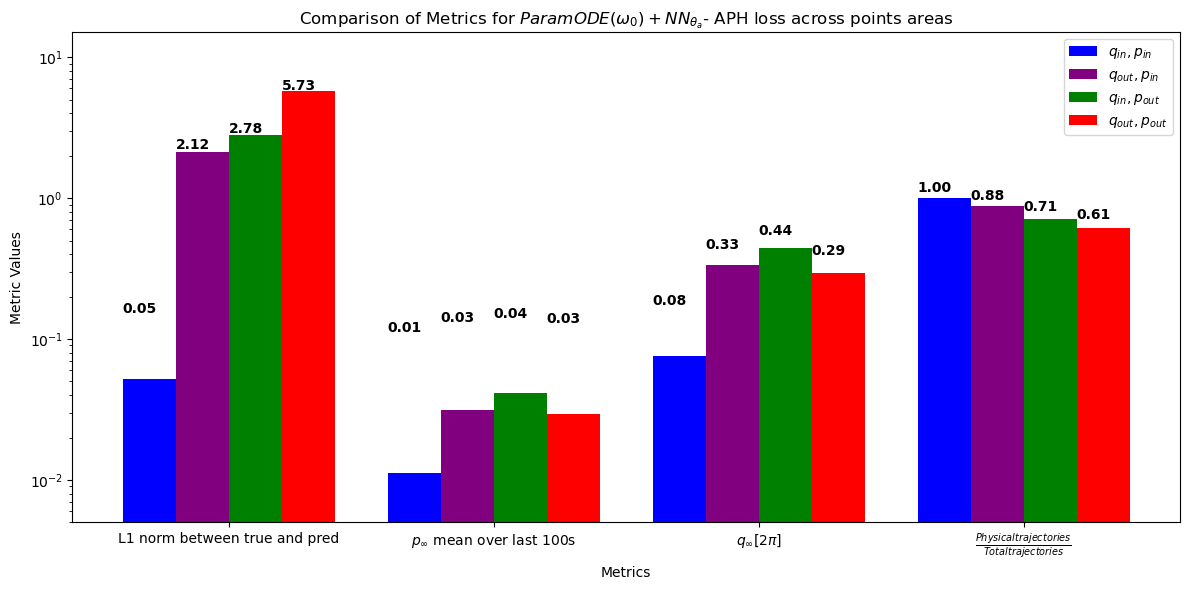

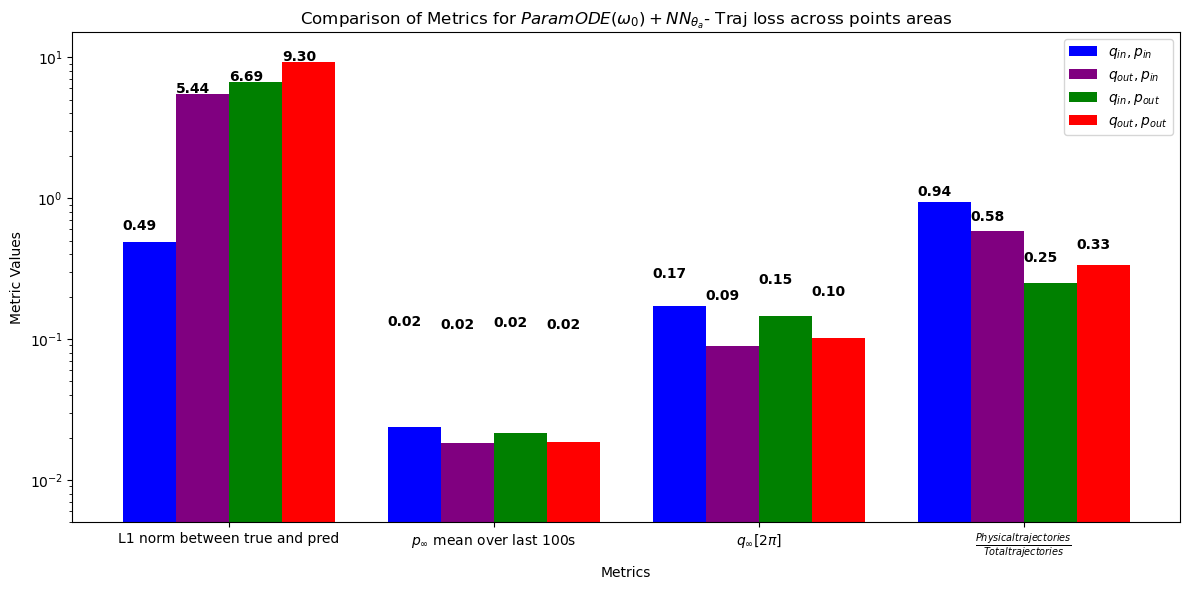

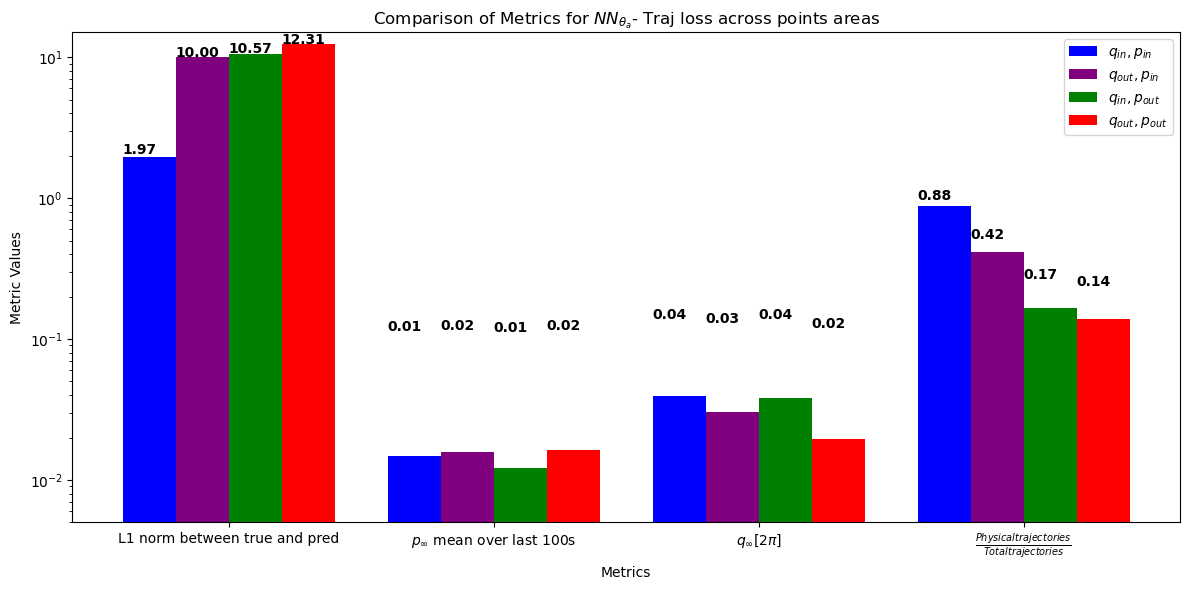

In [403]:
def bar_plot(dictionaries, name):
    metric_names = ['L1', 'p_inf_mean', 'q_inf_modulo2pi',  "physicality"]
    metrics_labels = ['L1 norm between true and pred', r'$p_{\infty}$ mean over last 100s', r'$q_{\infty} [2\pi]$',  r"$\frac{Physical trajectories}{Total trajectories}$"]

    # Convert single-element arrays to scalars where needed
    for d in dictionaries:
        for key in d.keys():
            if isinstance(d[key], np.ndarray):
                d[key] = d[key].item()

    # Prepare data for plotting
    n_metrics = len(metric_names)
    bar_width = 0.2
    x_indices = np.arange(n_metrics)

    # Plot each dictionary's values
    plt.figure(figsize=(12, 6))
    colors = ['b','purple', 'g', 'r']
    labels = [r'$q_{in},p_{in}$', r"$q_{out},p_{in}$", r"$q_{in},p_{out}$", r"$q_{out},p_{out}$"]

    for i, d in enumerate(dictionaries):
        values = [d[metric] for metric in metric_names]
        plt.bar(x_indices + i * bar_width, values, width=bar_width, color=colors[i], label=labels[i])

    # add values above bars 
    for i, d in enumerate(dictionaries):
        for j, metric in enumerate(metric_names):
            plt.text(j + i * bar_width - 0.1, d[metric] + 0.1, f"{d[metric]:.2f}", color='black', fontweight='bold')

    # Configure plot aesthetics
    plt.xticks(x_indices + bar_width * 1.5, metrics_labels)
    plt.ylabel('Metric Values')
    plt.xlabel('Metrics')
    plt.title(f'Comparison of Metrics for {name} across points areas')
    plt.legend()
    plt.yscale('log')
    plt.ylim(5e-3,15)

    plt.tight_layout()
    plt.show()

bar_plot([aph_in, aph_pin, aph_qin, aph_out], r"$ParamODE(\omega_0)+NN_{\theta_a}$- APH loss")
bar_plot([nofa_in, nofa_pin, nofa_qin, nofa_out], r"$ParamODE(\omega_0)+NN_{\theta_a}$- Traj loss")
bar_plot([nn_in, nn_pin, nn_qin, nn_out], r"$NN_{\theta_a}$- Traj loss")

In [428]:
dictionaries

[{'in': 1.9714175, 'pin': 10.004266, 'qin': 10.570216, 'out': 12.312749},
 {'in': 0.49047434, 'pin': 5.4428024, 'qin': 6.691686, 'out': 9.302989},
 {'in': 0.051801853, 'pin': 2.1229126, 'qin': 2.7821732, 'out': 5.732315}]

/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_46951/706748377.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1][0].legend()


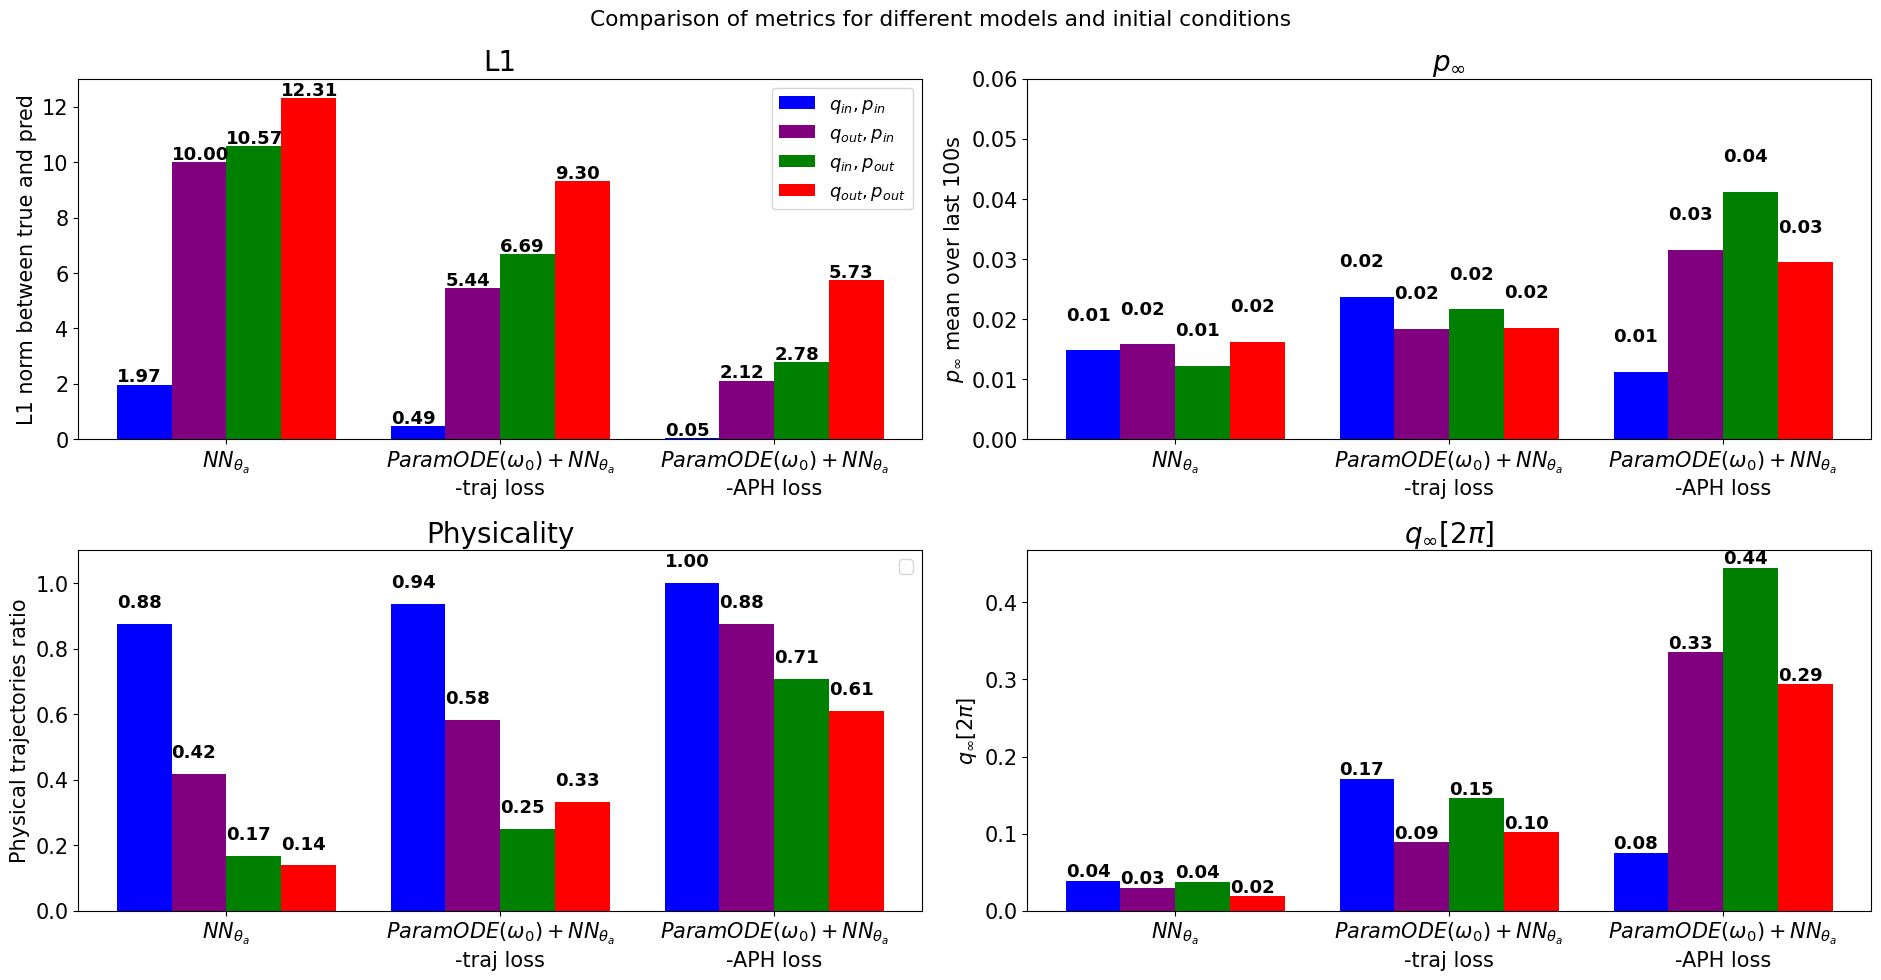

In [457]:
# L1 figure
L1_aph = { "in": aph_in["L1"], "pin": aph_pin["L1"], "qin": aph_qin["L1"], "out": aph_out["L1"]}
L1_nn = { "in": nn_in["L1"], "pin": nn_pin["L1"], "qin": nn_qin["L1"], "out": nn_out["L1"]}
L1_nofa = { "in": nofa_in["L1"], "pin": nofa_pin["L1"], "qin": nofa_qin["L1"], "out": nofa_out["L1"]}
dico = [L1_nn, L1_nofa, L1_aph]
phy_aph = { "in": aph_in["physicality"], "pin": aph_pin["physicality"], "qin": aph_qin["physicality"], "out": aph_out["physicality"]}
phy_nn = { "in": nn_in["physicality"], "pin": nn_pin["physicality"], "qin": nn_qin["physicality"], "out": nn_out["physicality"]}
phy_nofa = { "in": nofa_in["physicality"], "pin": nofa_pin["physicality"], "qin": nofa_qin["physicality"], "out": nofa_out["physicality"]}
dico_phy = [phy_nn, phy_nofa, phy_aph]

fig, ax = plt.subplots(2,2,figsize=(19, 10))
plt.rcParams.update({'font.size': 13})
# L1
colors = ['b','purple', 'g', 'r']
labels = [r'$q_{in},p_{in}$', r"$q_{out},p_{in}$", r"$q_{in},p_{out}$", r"$q_{out},p_{out}$"]
metrics_labels = [r'$NN_{\theta_a}$', r"$ParamODE(\omega_0)+NN_{\theta_a}$"+"\n"+"-traj loss", r"$ParamODE(\omega_0)+NN_{\theta_a}$"+"\n"+"-APH loss"]
metric_names = ['in', 'pin', 'qin', 'out']
bar_width = 0.2
x_indices = np.arange(len(dico))
for i, metric in enumerate(metric_names):
    values = [d[metric] for d in dico]
    ax[0][0].bar(x_indices + i * bar_width, values, width=bar_width, color=colors[i], label=labels[i])

# add values above bars 
for j, d in enumerate(dico):
    for i, metric in enumerate(metric_names):
        ax[0][0].text(j + i * bar_width - 0.1, d[metric] + 0.1, f"{d[metric]:.2f}", color='black', fontweight='bold')

ax[0][0].set_xticks(x_indices + bar_width * 1.5, metrics_labels)
ax[0][0].legend()
ax[0][0].set_ylabel('L1 norm between true and pred')
ax[0][0].set_ylim(0, 13)
# physicality
for i, metric in enumerate(metric_names):
    values = [d[metric] for d in dico_phy]
    ax[1][0].bar(x_indices + i * bar_width, values, width=bar_width, color=colors[i]) #, label=labels[i])
for j, d in enumerate(dico_phy):
    for i, metric in enumerate(metric_names):
        ax[1][0].text(j + i * bar_width - 0.1, d[metric] + 0.05, f"{d[metric]:.2f}", color='black', fontweight='bold')
ax[1][0].set_xticks(x_indices + bar_width * 1.5, metrics_labels)
ax[1][0].set_ylabel("Physical trajectories ratio")
ax[1][0].legend()
ax[1][0].set_ylim(0,1.1)

# p infinity
p_aph = { "in": aph_in["p_inf_mean"], "pin": aph_pin["p_inf_mean"], "qin": aph_qin["p_inf_mean"], "out": aph_out["p_inf_mean"]}
p_nn = { "in": nn_in["p_inf_mean"], "pin": nn_pin["p_inf_mean"], "qin": nn_qin["p_inf_mean"], "out": nn_out["p_inf_mean"]}
p_nofa = { "in": nofa_in["p_inf_mean"], "pin": nofa_pin["p_inf_mean"], "qin": nofa_qin["p_inf_mean"], "out": nofa_out["p_inf_mean"]}
dico_p = [p_nn, p_nofa, p_aph]

for i, metric in enumerate(metric_names):
    values = [d[metric] for d in dico_p]
    ax[0][1].bar(x_indices + i * bar_width, values, width=bar_width, color=colors[i]) #, label=labels[i])
for j, d in enumerate(dico_p):
    for i, metric in enumerate(metric_names):
        ax[0][1].text(j + i * bar_width - 0.1, d[metric] + 0.005, f"{d[metric]:.2f}", color='black', fontweight='bold')
ax[0][1].set_xticks(x_indices + bar_width * 1.5, metrics_labels)
ax[0][1].set_ylabel(r'$p_{\infty}$ mean over last 100s')
ax[0][1].set_ylim(0, 0.06)

# q modulo 2pi
q_aph = { "in": aph_in["q_inf_modulo2pi"], "pin": aph_pin["q_inf_modulo2pi"], "qin": aph_qin["q_inf_modulo2pi"], "out": aph_out["q_inf_modulo2pi"]}
q_nn = { "in": nn_in["q_inf_modulo2pi"], "pin": nn_pin["q_inf_modulo2pi"], "qin": nn_qin["q_inf_modulo2pi"], "out": nn_out["q_inf_modulo2pi"]}
q_nofa = { "in": nofa_in["q_inf_modulo2pi"], "pin": nofa_pin["q_inf_modulo2pi"], "qin": nofa_qin["q_inf_modulo2pi"], "out": nofa_out["q_inf_modulo2pi"]}
dico_q = [q_nn, q_nofa, q_aph]

for i, metric in enumerate(metric_names):
    values = [d[metric] for d in dico_q]
    ax[1][1].bar(x_indices + i * bar_width, values, width=bar_width, color=colors[i]) #, label=labels[i])
for j, d in enumerate(dico_q):
    for i, metric in enumerate(metric_names):
        ax[1][1].text(j + i * bar_width - 0.1, d[metric] + 0.005, f"{d[metric]:.2f}", color='black', fontweight='bold')
ax[1][1].set_xticks(x_indices + bar_width * 1.5, metrics_labels)
ax[1][1].set_ylabel(r'$q_{\infty} [2\pi]$')

ax[0][0].set_title("L1", fontsize=20)
ax[0][1].set_title(r'$p_{\infty}$', fontsize=20)
ax[1][0].set_title("Physicality", fontsize=20)
ax[1][1].set_title(r'$q_{\infty} [2\pi]$', fontsize=20)

fig.suptitle("Comparison of metrics for different models and initial conditions")
plt.tight_layout()
# police set 
